## Testing NVIDIA

---


In [ ]:
!nvidia-smi

Mon Jan  5 02:29:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install Dependencies

---


In [ ]:
!pip install pyarrow --quiet
!pip install transformers --quiet
!pip install datasets --quiet
!pip install -U torch torchvision torchaudio
!pip install scikit-learn --quiet
!pip install pandas --quiet
!pip install evaluate --quiet
!pip install tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5

## Cek Versi Transformers

---

In [ ]:
!pip show transformers
import transformers
print("Transformers version:", transformers.__version__)


Name: transformers
Version: 4.57.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers
Transformers version: 4.57.3


# Load & Split Dataset

---


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv(
    "data_train.csv",
    encoding="latin-1",
    on_bad_lines="skip"
)

# Rename kolom agar konsisten
df = df.rename(columns={
    "Tweet": "comment_text"
})

# Pastikan label numerik
label_cols = ["HS", "Abusive"]

for col in label_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Gabungkan label → toxic (biner)
df["label"] = df[label_cols].max(axis=1)

# Bersihkan data
df = df.dropna(subset=["comment_text"])
df = df.drop_duplicates(subset=["comment_text"])
df = df[df["comment_text"].str.strip() != ""]

# Split train / validation
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")


Train size: 11720, Validation size: 1303


## Tokenisasi Data dengan IndoBERT

---

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset   = Dataset.from_pandas(val_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(
    "indobenchmark/indobert-base-p1",
    use_fast=True
)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=["comment_text"])
val_dataset   = val_dataset.map(tokenize_function, batched=True, remove_columns=["comment_text"])

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset   = val_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/11720 [00:00<?, ? examples/s]

Map:   0%|          | 0/1303 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

# Ambil 3 teks pertama
sample_texts = train_df["comment_text"].iloc[:8].tolist()

rows = []

for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    length = len(tokens)

    rows.append({
        "Text": text,
        "Tokens": "[" + ", ".join(tokens) + "]",
        "Length": length
    })

# Buat tabel
df_visual = pd.DataFrame(rows)
df_visual


,Text,Tokens,Length
0,"USER USER USER si mahfud sekarang beda, sptnya...","[user, user, user, si, mahfud, sekarang, beda,...",24
1,USER USER USER kalau agama lain anda bilang ka...,"[user, user, user, kalau, agama, lain, anda, b...",37
2,USER Stupid question. Kalo mau ngentod gak usa...,"[user, stu, ##pi, ##d, question, ., kalo, mau,...",18
3,Agak horror juga dapet smirk dari orang asing',"[agak, hor, ##ror, juga, dapet, sm, ##ir, ##k,...",12
4,RT USER: Prabowo Subianto Gagal maju URL,"[rt, user, :, prabowo, subianto, gagal, maju, ...",8
5,USER katanya pemerintah lagi menjunjung tinggi...,"[user, katanya, pemerintah, lagi, menjunjung, ...",29
6,USER klo seiman nipu hukumnya halal ga mgkin d...,"[user, klo, sei, ##man, nip, ##u, hukumnya, ha...",18
7,Keberpihakan pada aseng tentunya . Gak terbant...,"[keber, ##pihak, ##an, pada, as, ##eng, tentun...",13


## Load Model IndoBERT dan Penyiapan Metrik Evaluasi

---


In [ ]:
from transformers import AutoModelForSequenceClassification
import evaluate

model_name = "indobenchmark/indobert-base-p1"

# Load model tanpa safe_serialization
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2, # Karena klasifikasi 2 kelas
    torch_dtype="auto" # Otomatis pakai FP16
)

# Load metric F1 untuk evaluasi
metric = evaluate.load("f1")

# Fungsi untuk menghitung metric selama evaluasi
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return metric.compute(predictions=preds, references=labels)


`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Setup TrainingArguments dan Trainer

---

In [ ]:
from transformers import TrainingArguments, Trainer

# Konfigurasi
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",             # eval berdasarkan jumlah steps
    eval_steps=500,                    # evaluasi tiap 500 training steps
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    save_steps=500,                    # Save model setiap 500 steps
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=100,                 # log setiap 100 steps
    report_to=[],
)

# Inisialisasi Trainer
trainer = Trainer(
    model=model,                       # Model
    args=args,                         # Argumen training
    train_dataset=train_dataset,       # Dataset training
    eval_dataset=val_dataset,          # Dataset evaluasi/validasi
    tokenizer=tokenizer,               # Tokenizer
    compute_metrics=compute_metrics,
)


/tmp/ipython-input-358516715.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## Training Model IndoBERT

---

In [ ]:
# mulai latih modelnya
trainer.train()


Step,Training Loss,Validation Loss,F1
500,0.314900,0.299677,0.885050
1000,0.149700,0.397430,0.890037
1500,0.145500,0.493121,0.906166
2000,0.039700,0.468738,0.915464


TrainOutput(global_step=2199, training_loss=0.18557574988604134, metrics={'train_runtime': 1022.1512, 'train_samples_per_second': 34.398, 'train_steps_per_second': 2.151, 'total_flos': 2312746176614400.0, 'train_loss': 0.18557574988604134, 'epoch': 3.0})

## Grafik Training & Validation Loss

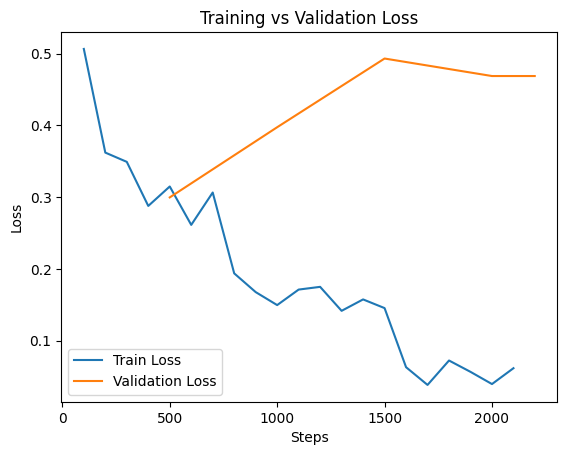

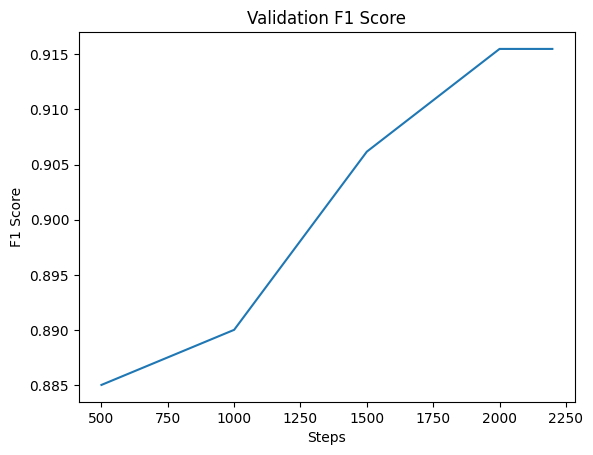

In [ ]:
import matplotlib.pyplot as plt

# Ambil log history
logs = trainer.state.log_history

train_loss = []
eval_loss = []
eval_f1 = []
steps_train = []
steps_eval = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        steps_train.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        eval_f1.append(log.get("eval_f1"))
        steps_eval.append(log["step"])

# Plot loss
plt.figure()
plt.plot(steps_train, train_loss)
plt.plot(steps_eval, eval_loss)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

# Plot F1 score
plt.figure()
plt.plot(steps_eval, eval_f1)
plt.xlabel("Steps")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score")
plt.show()


## Grafik Confusion Matrix

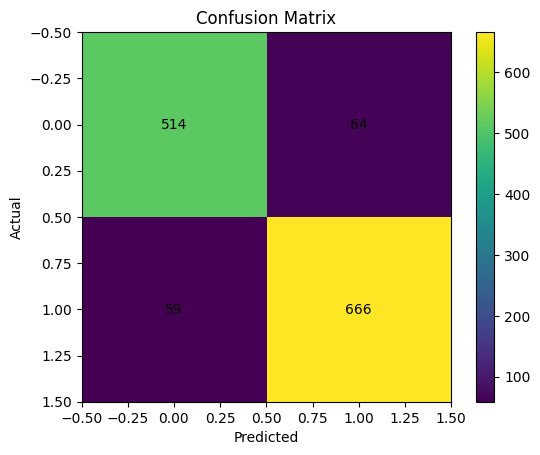

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(labels, preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


## Grafik Distribusi Prediksi

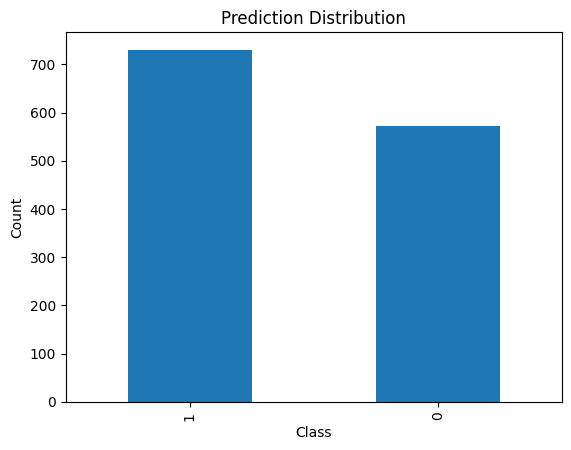

In [ ]:
import pandas as pd

pred_df = pd.DataFrame({
    "label": labels,
    "prediction": preds
})

pred_df["prediction"].value_counts().plot(kind="bar", title="Prediction Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


## Evaluasi Prediksi Model

---

In [ ]:

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json
import pandas as pd

#Evaluasi via Trainer
eval_results = trainer.evaluate(eval_dataset=val_dataset)
print("=== Eval results (Trainer) ===")
print(eval_results)

# Prediksi validation set
preds_output = trainer.predict(val_dataset)
logits = preds_output.predictions
preds = np.argmax(logits, axis=-1)
labels = preds_output.label_ids

print("\n=== Classification report (sklearn) ===")
print(classification_report(labels, preds, digits=4))

print("\n=== Confusion matrix ===")
print(confusion_matrix(labels, preds))

print("\n=== Accuracy ===")
print(accuracy_score(labels, preds))

# Simpan metrik & prediksi
metrics_summary = {
    "trainer_eval_results": eval_results,
    "accuracy": float(accuracy_score(labels, preds)),
}

# mengembalikan f1 di eval_results
if "eval_f1" in eval_results:
    metrics_summary["f1_from_trainer"] = float(eval_results["eval_f1"])

# simpan json metrik
with open("eval_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

# simpan prediksi per-sample
pd.DataFrame({
    "text": val_df["comment_text"].values,
    "label": labels,
    "prediction": preds
}).to_csv("val_predictions.csv", index=False)

print("\nSaved eval_metrics.json and val_predictions.csv")


=== Eval results (Trainer) ===
{'eval_loss': 0.46873757243156433, 'eval_f1': 0.9154639175257732, 'eval_runtime': 8.8385, 'eval_samples_per_second': 147.424, 'eval_steps_per_second': 9.278, 'epoch': 3.0}

=== Classification report (sklearn) ===
              precision    recall  f1-score   support

           0     0.8970    0.8893    0.8931       578
           1     0.9123    0.9186    0.9155       725

    accuracy                         0.9056      1303
   macro avg     0.9047    0.9039    0.9043      1303
weighted avg     0.9055    0.9056    0.9056      1303


=== Confusion matrix ===
[[514  64]
 [ 59 666]]

=== Accuracy ===
0.9056024558710668

Saved eval_metrics.json and val_predictions.csv


## Simpan Model dan Tokenizer

---


In [ ]:
# penyimpanan modelnya
trainer.save_model("./toxic_model_id")
tokenizer.save_pretrained("./toxic_model_id")


('./toxic_model_id/tokenizer_config.json',
 './toxic_model_id/special_tokens_map.json',
 './toxic_model_id/vocab.txt',
 './toxic_model_id/added_tokens.json',
 './toxic_model_id/tokenizer.json')

## Uji Model Toxic Comment Classification

---

In [ ]:
from transformers import pipeline

# Model dan tokenizer dari folder "toxic_model_id"
classifier = pipeline("text-classification", model="./toxic_model_id", tokenizer="./toxic_model_id")

#testing model
print(classifier("anjir kamu bego banget"))
print(classifier("alan cuki kamu"))
print(classifier("ayo mabar mobile legend kim"))


Device set to use cuda:0


[{'label': 'LABEL_1', 'score': 0.9996708631515503}]
[{'label': 'LABEL_0', 'score': 0.9991742968559265}]
[{'label': 'LABEL_0', 'score': 0.9993796348571777}]
